## Validate 15MW turbine interpolations

In [123]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wrf_io import postproc
from MITRotor import IEA15MW, BEMGeometry

In [125]:
blue   = sns.color_palette("tab10")[0]
orange = sns.color_palette("tab10")[1]

In [126]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [127]:
rotor = IEA15MW()
geom  = BEMGeometry(Nr=32,Ntheta=191,R=rotor.R, Rhub=rotor.hub_radius)


In [128]:
# r/R from WRF
r = np.array([4.7759555E-02, 7.7989414E-02, 0.1082193    , 0.1384491    , 0.1686790    , 0.1989089    , 0.2291387    , 0.2593686    , 0.2895984    , 0.3198283    , 0.3500582    , 0.3802881    , 0.4105179    , 0.4407478    , 0.4709777    , 0.5012075    , 0.5314374    , 0.5616672    , 0.5918970    , 0.6221268    , 0.6523566    , 0.6825864    , 0.7128162    , 0.7430460    , 0.7732759    , 0.8035057    , 0.8337355    , 0.8639653    , 0.8941951    , 0.9244249    , 0.9546546    , 0.9848844    ])

In [129]:
# Airfoil ID at each r/R from WRF
airfoil_ID = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8])

In [130]:
# Verify MITRotor and WRF compute the same airfoil ID at each r/R
rotor.airfoil_func.airfoil_id_from_interp(r) == airfoil_ID

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

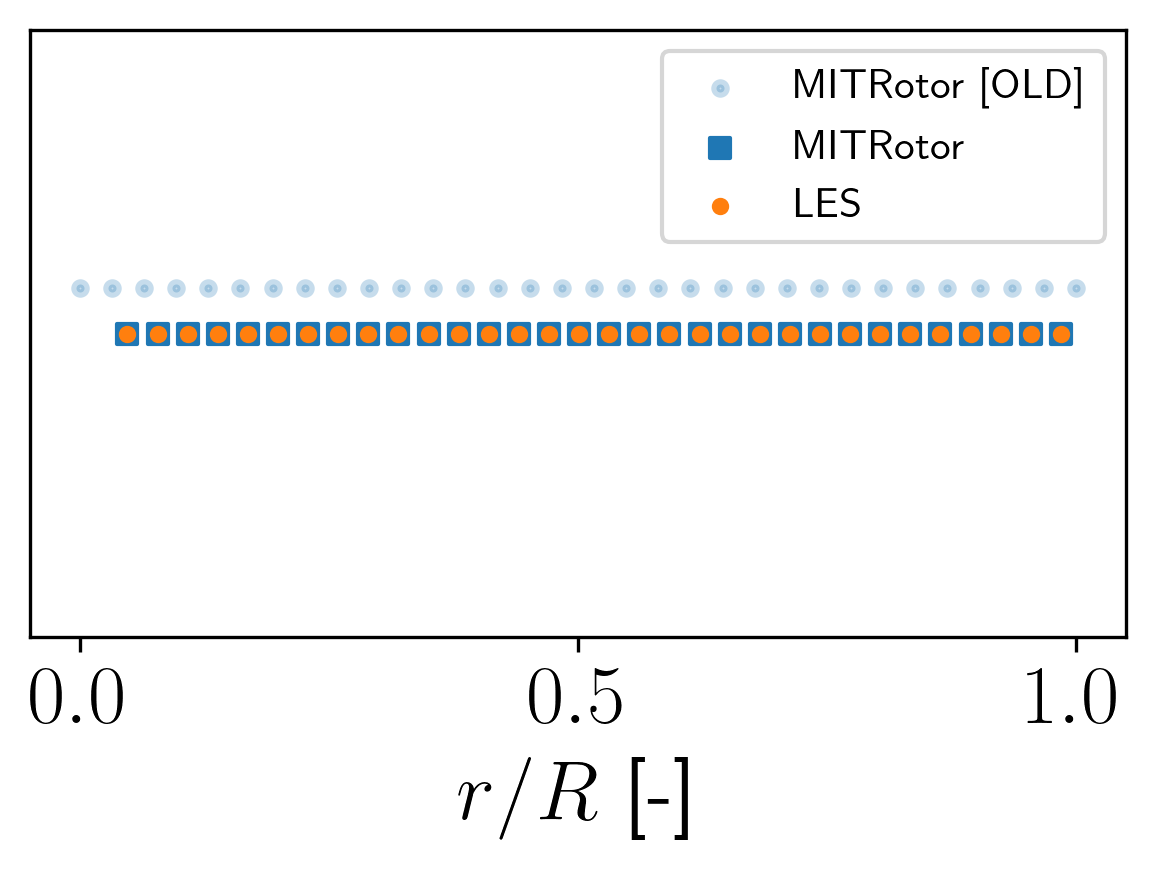

In [141]:
fig, ax = plt.subplots(figsize=(4, 3))


ax.scatter(np.linspace(0,1,32),0.15*np.ones_like(r), 15,zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.',label='MITRotor [OLD]')
ax.scatter(geom.mu,0*np.ones_like(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,0*np.ones_like(r),10,marker='o', color=orange,label='LES')

ax.set_yticks([])

ax.set_ylim([-1,1])
ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
# ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

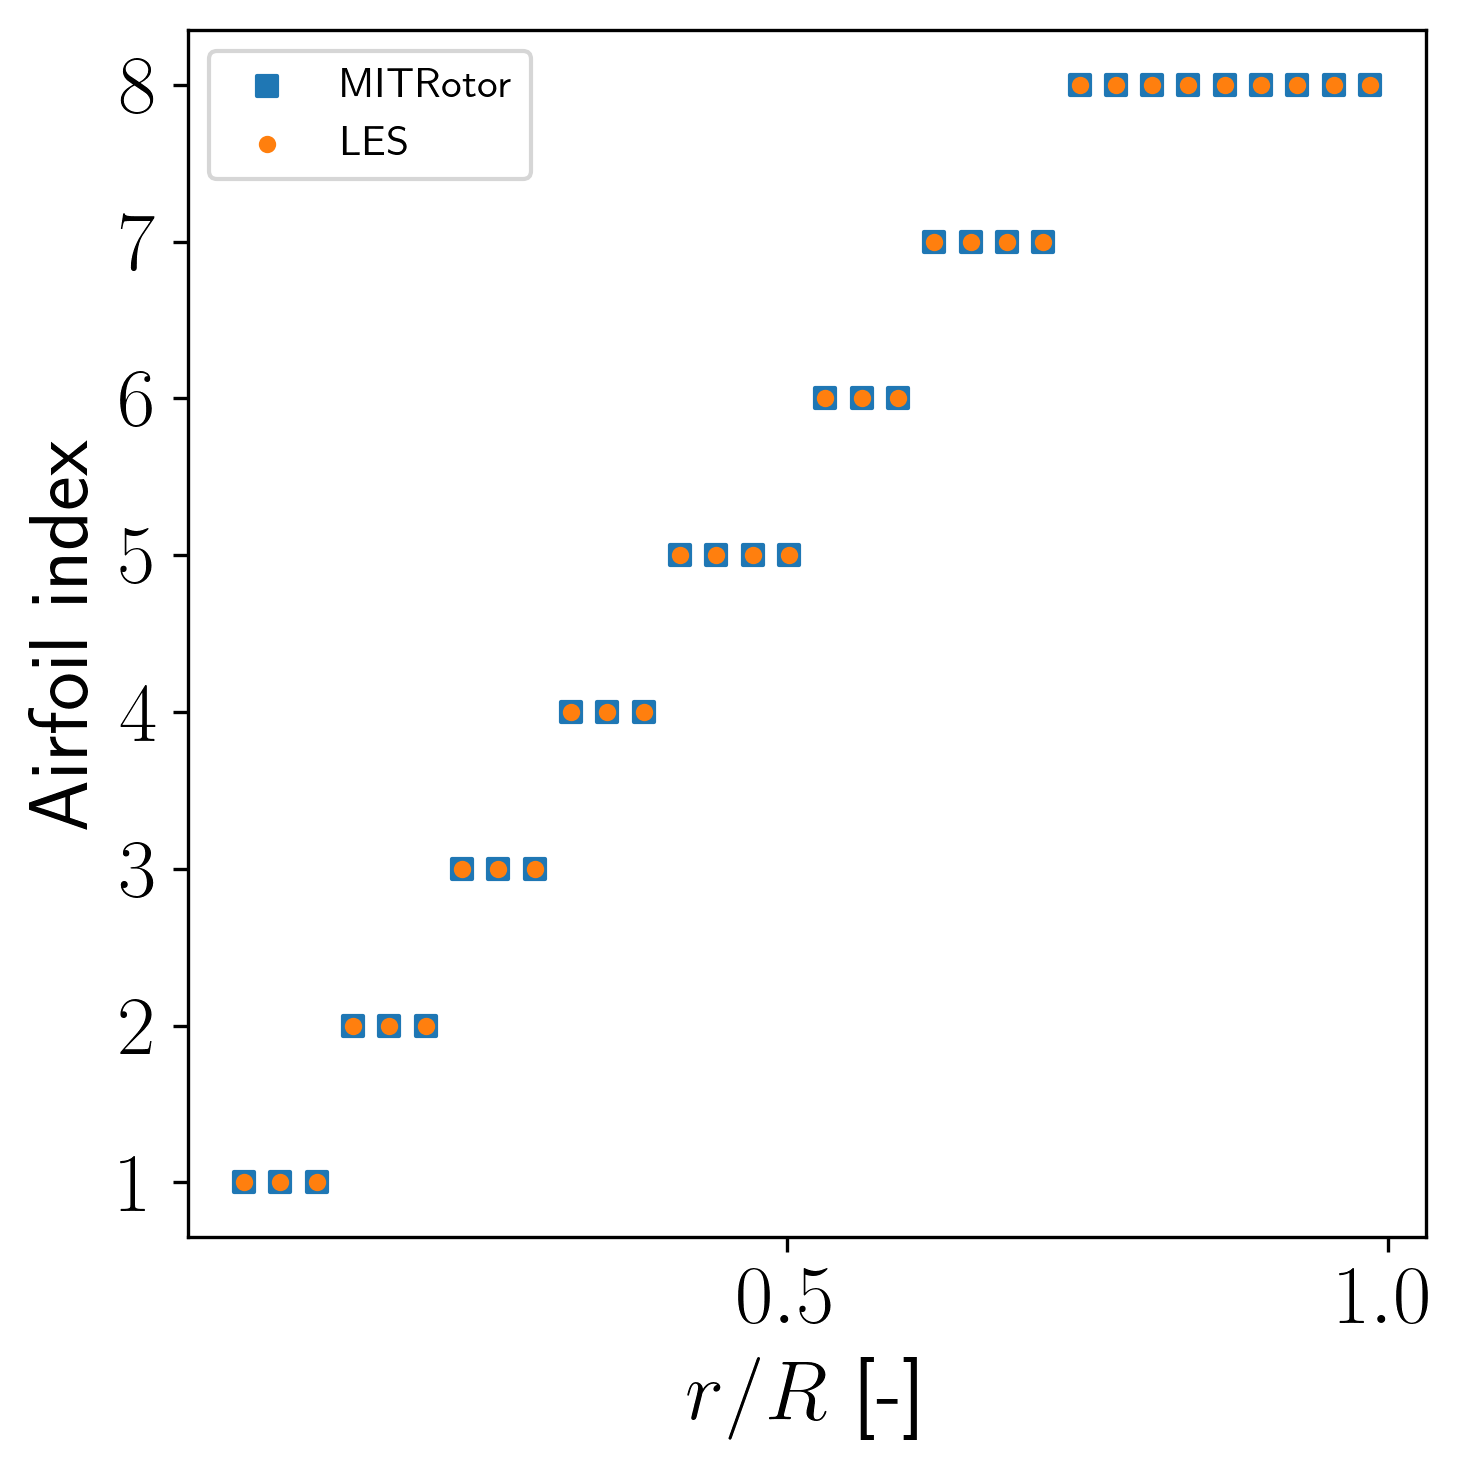

In [132]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(r,rotor.airfoil_func.airfoil_id_from_interp(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,airfoil_ID,10,marker='o', color=orange,label='LES')

unique_ids = np.unique(airfoil_ID)
ax.set_yticks(unique_ids)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

In [133]:
# airfoil names
airfoil_names = np.array(['circular', 'circular', 'SNL-FFA-W3-500', 'FFA-W3-360', 'FFA-W3-330blend', 'FFA-W3-301', 'FFA-W3-270blend', 'FFA-W3-241', 'FFA-W3-211', 'FFA-W3-211'])
airfoil_names

array(['circular', 'circular', 'SNL-FFA-W3-500', 'FFA-W3-360',
       'FFA-W3-330blend', 'FFA-W3-301', 'FFA-W3-270blend', 'FFA-W3-241',
       'FFA-W3-211', 'FFA-W3-211'], dtype='<U15')

In [134]:
airfoil_mu = np.array([0.03264463, 0.05199174, 0.17774793, 0.26981145, 0.35075359, 0.45748713, 0.55276395, 0.65001823, 0.77919519, 1.0])
airfoil_mu

array([0.03264463, 0.05199174, 0.17774793, 0.26981145, 0.35075359,
       0.45748713, 0.55276395, 0.65001823, 0.77919519, 1.        ])

In [135]:
airfoil_r = airfoil_mu * rotor.R
airfoil_r

array([  3.95000023,   6.29100054,  21.50749953,  32.64718545,
        42.44118439,  55.35594273,  66.88443795,  78.65220583,
        94.28261799, 121.        ])

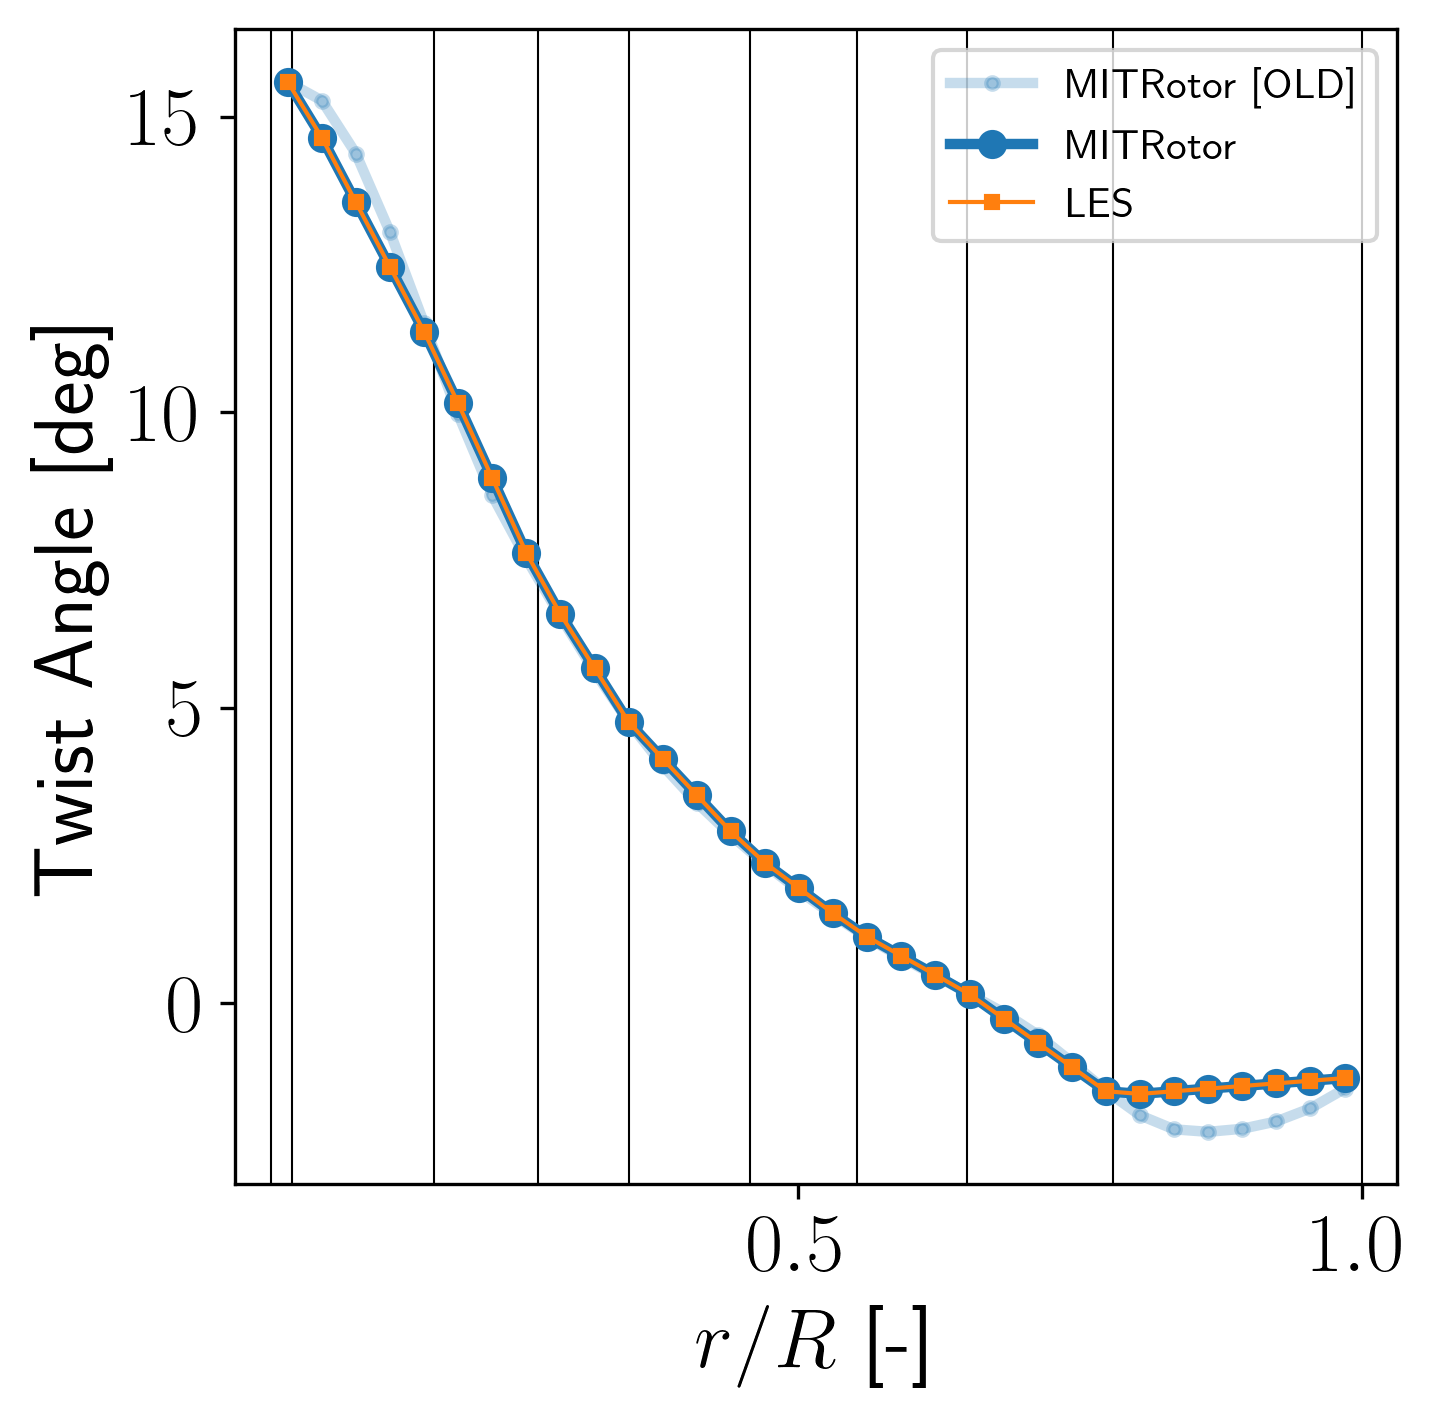

In [136]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, np.rad2deg(rotor.twist_func_old(r)), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r, np.rad2deg(rotor.twist_func(r)), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r, [15.58937    ,  14.64691    ,  13.55274    ,  12.45857    ,  11.36440    ,  10.15042    ,  8.885125    ,  7.619830    ,  6.585517    ,  5.673080    ,  4.760644    ,  4.138330    ,  3.522831    ,  2.907332    ,  2.375858    ,  1.948647    ,  1.521437    ,  1.125323    , 0.8036481    , 0.4819737    , 0.1534523    ,-0.2566732    ,-0.6667988    , -1.076924    , -1.487050    , -1.531622    , -1.487126    , -1.442631    , -1.398135    , -1.353640    , -1.309144    , -1.264649],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Twist Angle [deg]',fontsize=fontsize)
ax.legend()

plt.show()

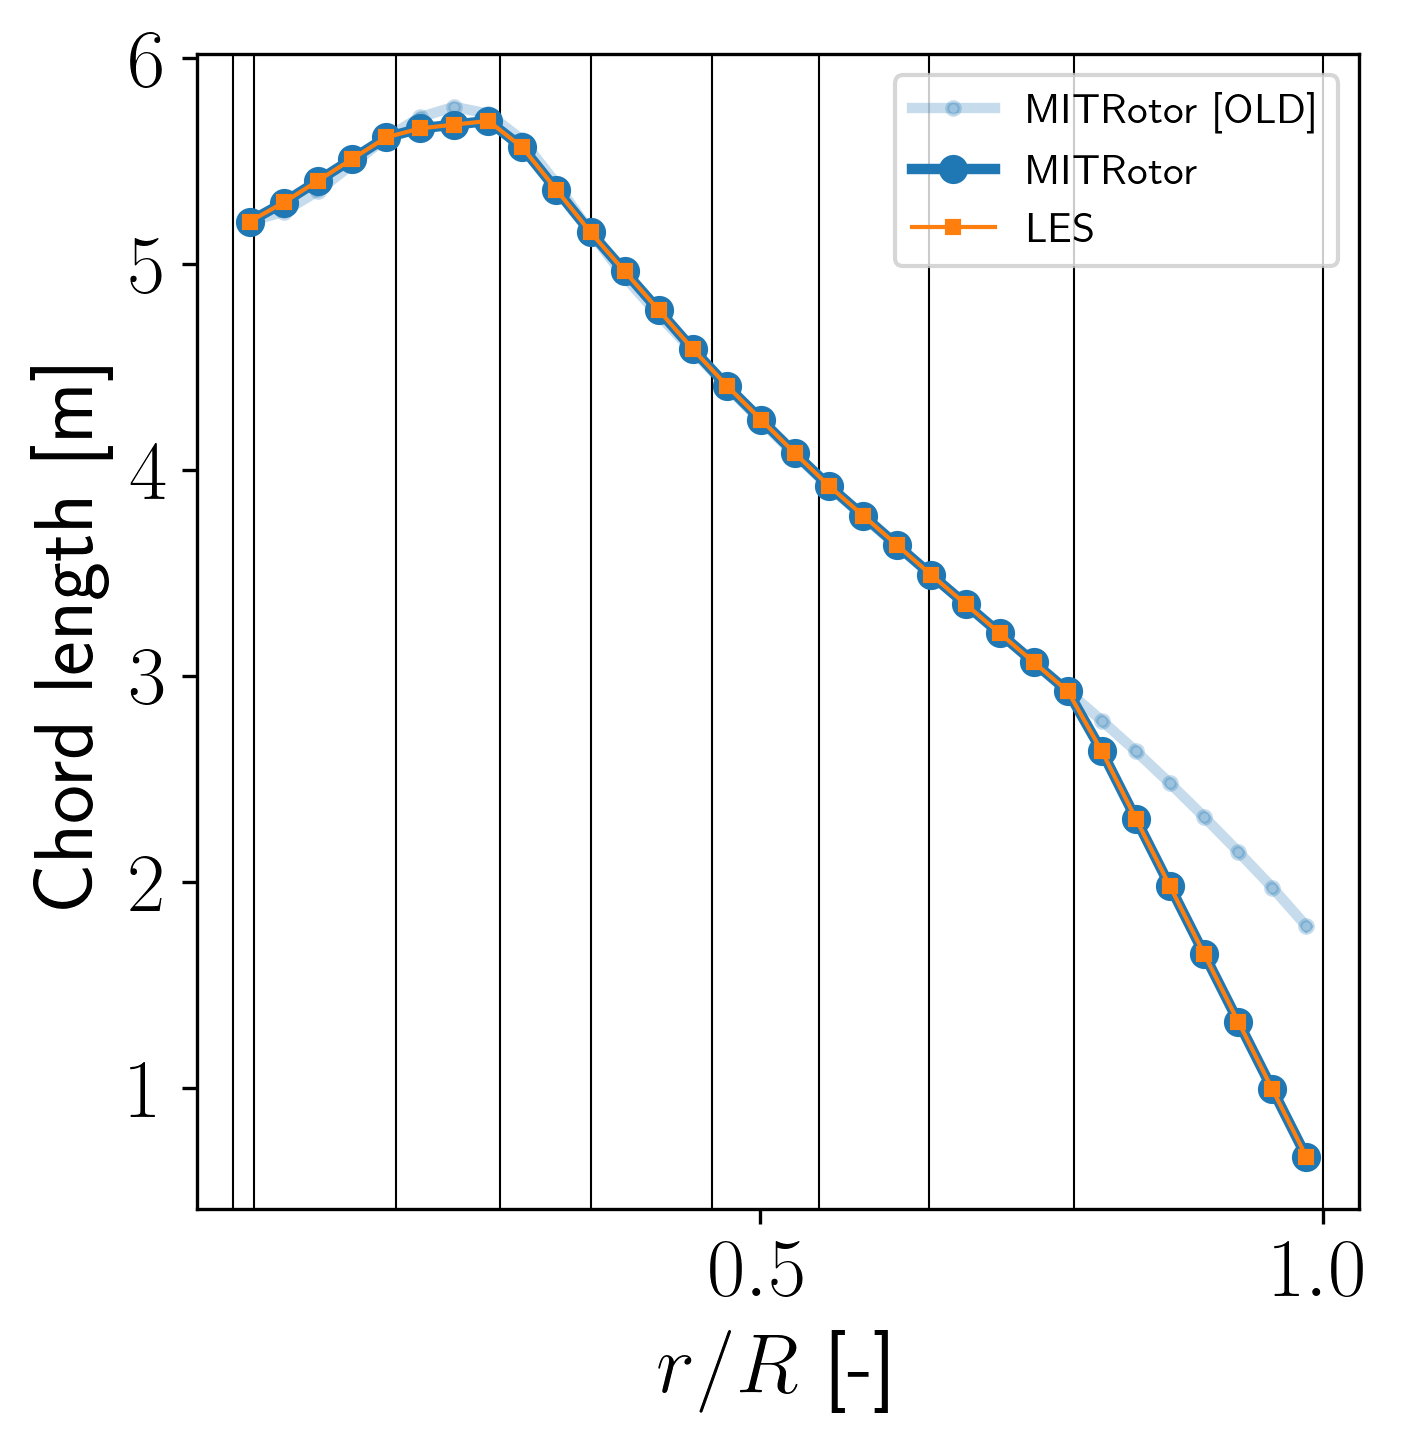

In [137]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, rotor.chord_func_old(r), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,rotor.chord_func(r), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[5.206797, 5.299231, 5.404498, 5.509766, 5.615034, 5.659290, 5.677414, 5.695539, 5.566848, 5.360690, 5.154532, 4.965116, 4.776093, 4.587071, 4.409054, 4.244694, 4.080333, 3.921934, 3.777803, 3.633673, 3.489777, 3.348669, 3.207561, 3.066453, 2.925345, 2.633745, 2.305478, 1.977210, 1.648943, 1.320675, 0.9924080, 0.6641405],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Chord length [m]',fontsize=fontsize)
ax.legend()

In [138]:
# Evaluate CL and CD in MITRotor
Cl, Cd = rotor.clcd(r, np.deg2rad(np.array([50.571, 40.036, 31.920, 24.680, 19.090, 15.277, 12.498, 10.722, 9.618, 8.923, 8.472, 8.001, 7.755, 7.565, 7.348, 7.160, 7.075, 6.988, 6.870, 6.818, 6.783, 6.826, 6.898, 7.000, 7.152, 7.075, 7.018, 6.994, 6.981, 6.976, 6.985, 7.086])))

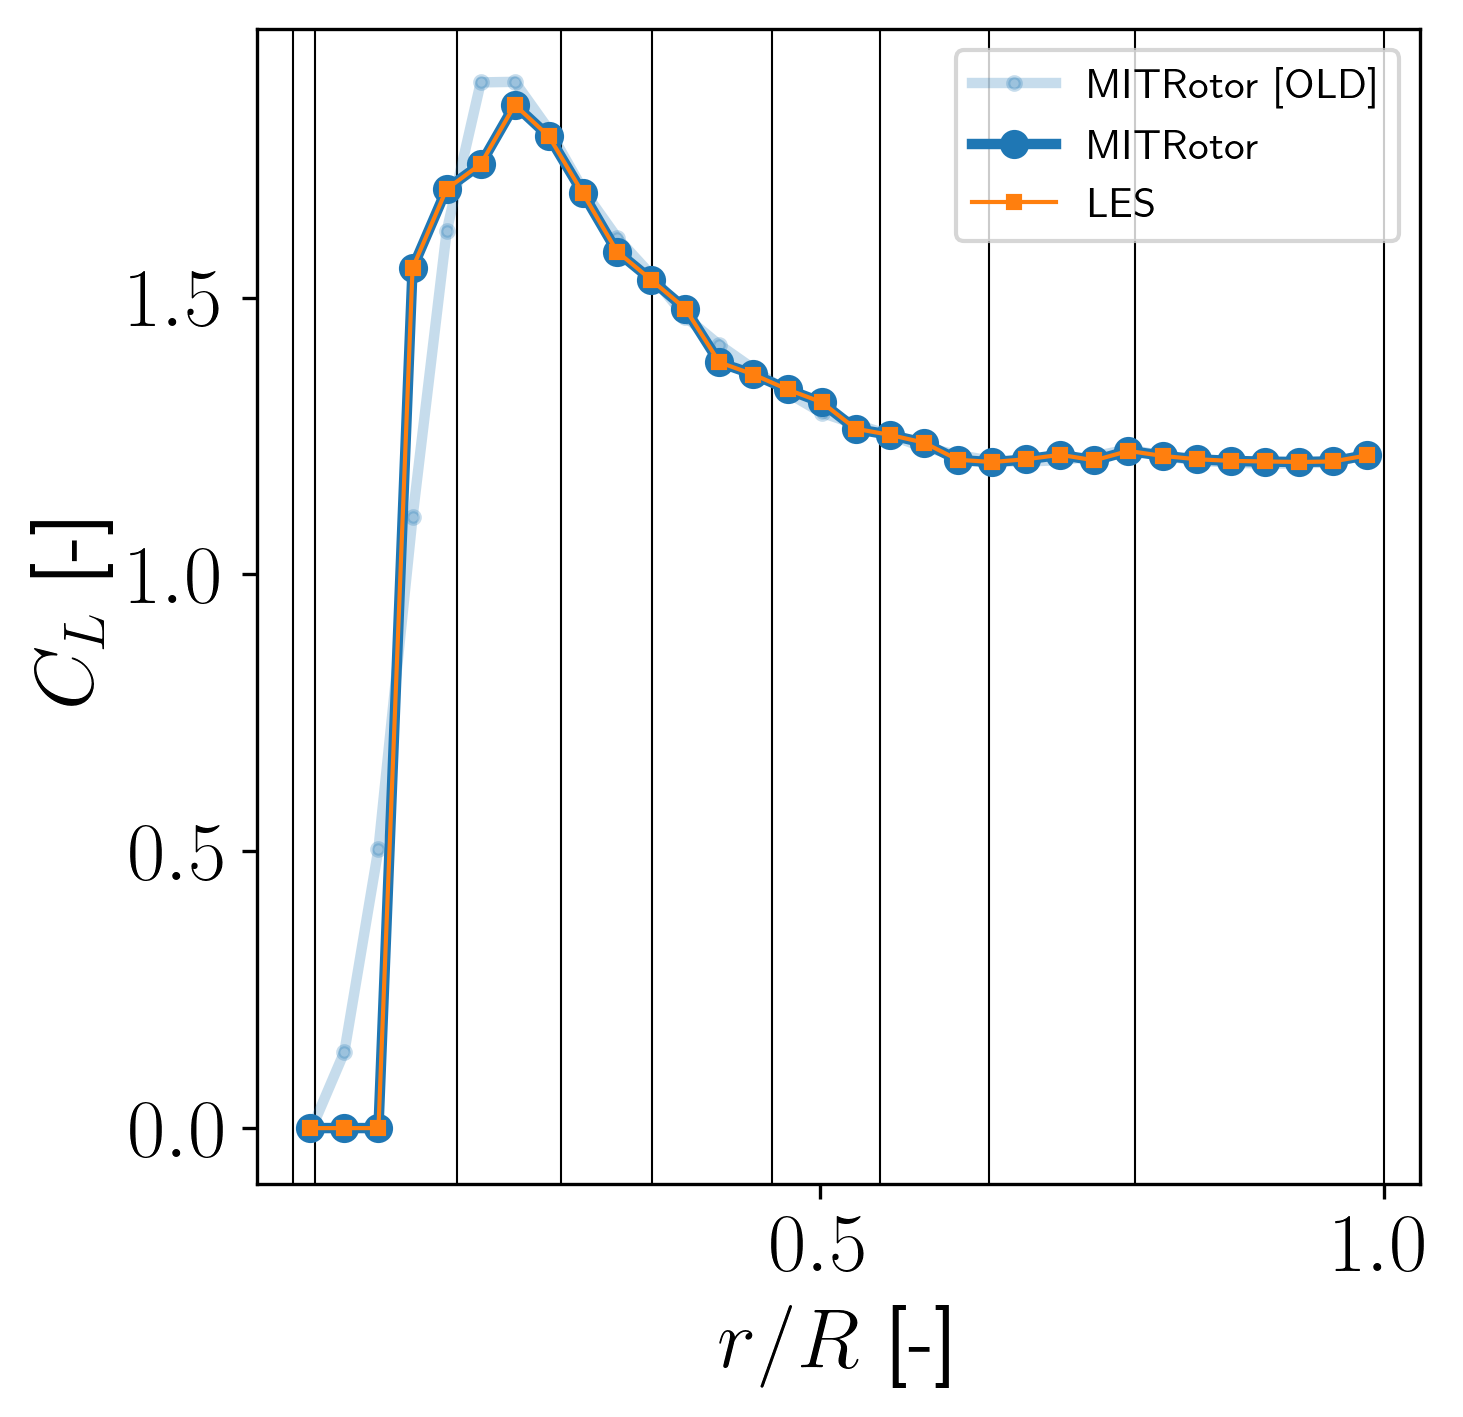

In [139]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[-0.00673724,  0.1376296 ,  0.50471911,  1.10346009,  1.61962122,1.888567  ,  1.88957278,  1.80306259,  1.69457556,  1.60799856,1.540833  ,  1.4652213 ,  1.41440504,  1.37125803,  1.3280041 ,1.29206135,  1.27121614,  1.25170303,  1.22939702,  1.21570259,1.20479798,  1.2036863 ,  1.20650537,  1.21323995,  1.22595159,1.21428176,  1.20580259,  1.20186357,  1.20006531,  1.20009494,1.20262855,  1.21622948], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,Cl, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.000,0.000,0.000,1.553,1.696,1.741,1.848,1.791,1.688,1.583,1.532,1.480,1.383,1.361,1.334,1.311,1.263,1.252,1.238,1.207,1.203,1.208,1.216,1.206,1.223,1.214,1.208,1.205,1.204,1.203,1.204,1.215],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_L$ [-]',fontsize=fontsize)
ax.legend()

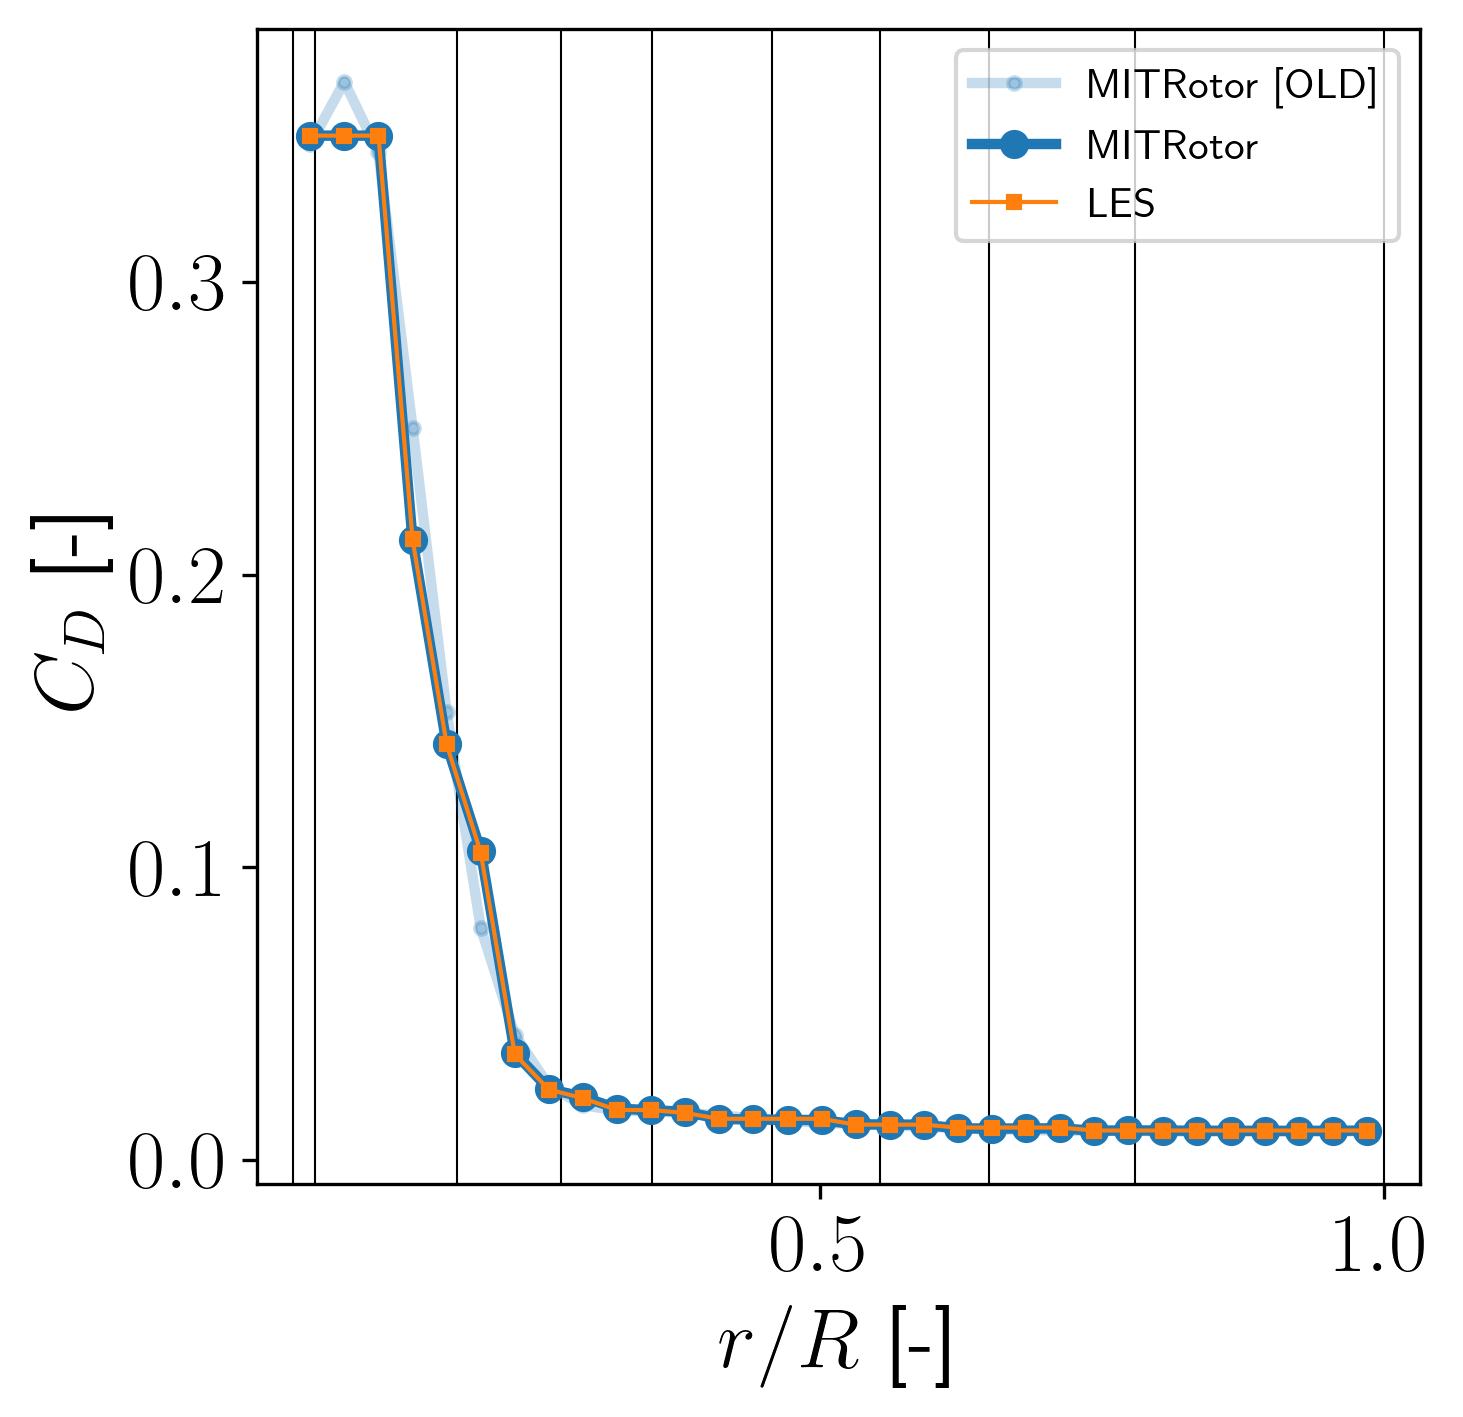

In [140]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[0.34709975, 0.36838097, 0.34424319, 0.25019381, 0.15291138,0.07929152, 0.04271647, 0.02517601, 0.0186468 , 0.01684266,0.01660947, 0.01602748, 0.01517512, 0.0141958 , 0.01331552,0.012678  , 0.01223559, 0.01181015, 0.01132612, 0.01088213,0.01047822, 0.01019128, 0.00999475, 0.00989561, 0.00992342,0.00974253, 0.00961553, 0.0095593 , 0.00954483, 0.00956463,0.00962142, 0.00980072], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')

ax.plot(r,Cd, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.350,0.350,0.350,0.212,0.142,0.105,0.036,0.024,0.021,0.017,0.017,0.016,0.014,0.014,0.014,0.014,0.012,0.012,0.012,0.011,0.011,0.011,0.011,0.010,0.010,0.010,0.010,0.010,0.010,0.010,0.010,0.010],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_D$ [-]',fontsize=fontsize)
ax.legend()